## ANALYSIS - EXPLORATORY DATA ANALYSIS & BUSINESS INSIGHTS

Notebook này tập trung vào việc thực hiện:
    - Phân tích Khám phá Dữ liệu (EDA) chuyên sâu nhằm giải mã bài toán cốt lõi của doanh nghiệp. 
    - Xác định các tác nhân gây ra tình trạng biên lợi nhuận (Margin) âm mặc dù quy mô doanh thu duy trì ở mức cao.
    - Mục tiêu cuối cùng là trích xuất các đặc trưng (features) quan trọng để cung cấp cho các giai đoạn tiền xử lý và huấn luyện mô hình học máy tiếp theo.

Chúng tôi tiếp cận bài toán thông qua 5 trụ cột phân tích trọng tâm:
1. Financial Health & Macro Trends: Đánh giá tương quan giữa tăng trưởng doanh thu và hiệu suất sinh lời qua các giai đoạn.

2. Discount Dependency Analysis: Định lượng mức độ lệ thuộc vào các chương trình khuyến mãi và tác động của chúng tới dòng tiền.

3. Product Portfolio Performance: Phân loại danh mục sản phẩm theo quy tắc Pareto 80/20 và xác định các nhóm hàng "ngôi sao" có biên lợi nhuận cao (nhóm Standard).

4. Customer Persona & Lifecycle: Phân tích hành vi mua sắm theo nhân khẩu học (đặc biệt là nhóm 55+) và chu kỳ tái mua hàng (175 ngày).

5. Operational & Channel Efficiency: Nhận diện các điểm nghẽn vận hành (trả hàng, hủy đơn) và hiệu quả chuyển đổi theo từng kênh (Email, Region).

**Mục lục**:
1. [Thiết lập và cài đặt](#1)
2. [Triển khai & Trực quan hóa](#2)
3. [Kết luận & Đề xuất đặc trưng](#3)

<a id="1"></a>

## 1. Thiết lập và cài đặt
Nhập các thư viện cần thiết và kết nối database `datathon.duckdb`

In [ ]:
import sys
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Kết nối Database để lấy dữ liệu gốc
sys.path.append(str(Path('..').resolve()))
from src.get_data import get_connection
con = get_connection()

# Cấu hình hiển thị
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

<a id="1"></a>

## 2. Triển khai & Trực quan hóa


## 2.1 Nhóm Biến Trực tiếp (Direct Transactional Drivers)
Đây là những biến nằm trong xuất hiện của phép tính doanh thu. Thay đổi bất kỳ biến nào ở đây cũng làm Revenue thay đổi ngay lập tức.

- Giá & Chi phí (products.csv): price (Giá bán lẻ) và cogs (Giá vốn). Mối quan hệ giữa hai biến này quyết định biên lợi nhuận.
- Số lượng (order_items.csv, inventory.csv): quantity (Số lượng mua) và units_sold. Revenue tỷ lệ thuận với số lượng bán ra.
- Giảm giá (promotions.csv, order_items.csv): discount_amount, promo_value. Đây là biến "trừ" vào Revenue nhưng lại là biến "kích" số lượng đơn hàng.

### 2.1.1 Revenue vs COGS

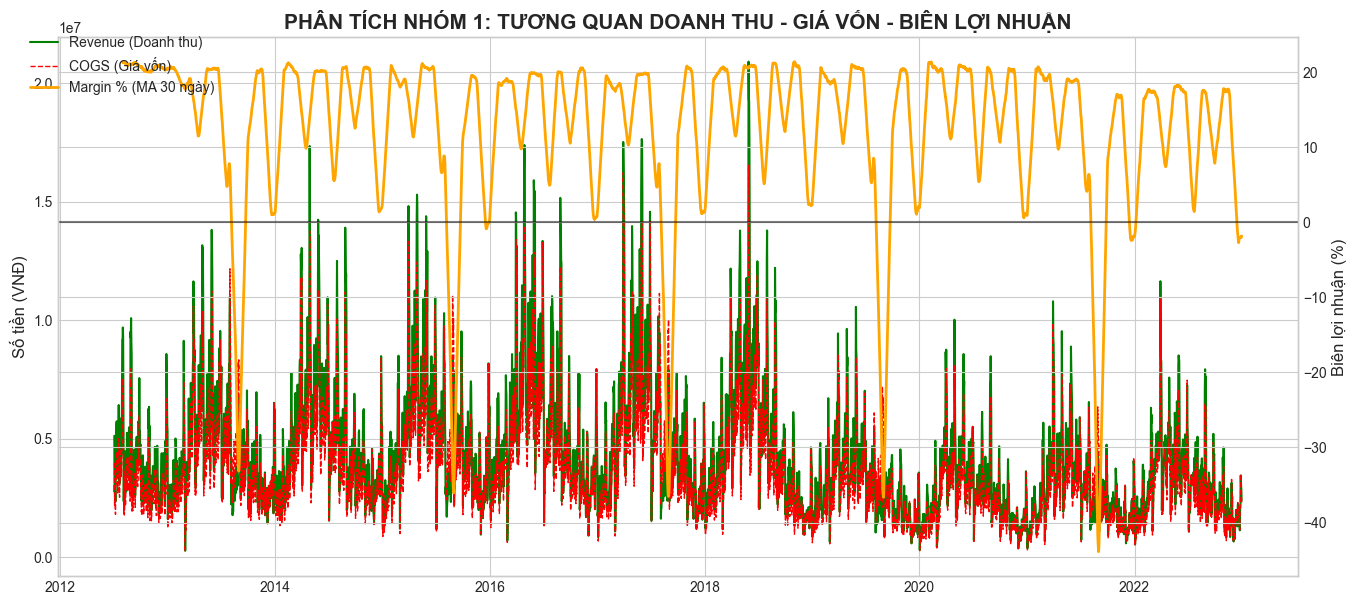

In [39]:
# Truy vấn trực tiếp từ bảng sales
# Lưu ý: DuckDB thường trả về tên cột viết thường, mình sẽ dùng .columns để kiểm tra nếu cần
df_finance = con.execute("""
    SELECT 
        CAST(Date AS DATE) as date,
        Revenue as revenue,
        COGS as cogs,
        (Revenue - COGS) as gross_profit
    FROM sales
    ORDER BY date
""").df()

# Tính toán biên lợi nhuận (Margin)
df_finance['margin_pct'] = (df_finance['gross_profit'] / df_finance['revenue']) * 100

# Vẽ biểu đồ
fig, ax1 = plt.subplots(figsize=(16, 7))

# Trục 1: Revenue và COGS
ax1.plot(df_finance['date'], df_finance['revenue'], label='Revenue (Doanh thu)', color='green', lw=1.5)
ax1.plot(df_finance['date'], df_finance['cogs'], label='COGS (Giá vốn)', color='red', lw=1, linestyle='--')
ax1.fill_between(df_finance['date'], df_finance['cogs'], df_finance['revenue'], 
                 where=(df_finance['revenue'] > df_finance['cogs']), facecolor='green', alpha=0.15)
ax1.set_ylabel('Số tiền (VNĐ)', fontsize=12)

# Trục 2: Biên lợi nhuận
ax2 = ax1.twinx()
ax2.plot(df_finance['date'], df_finance['margin_pct'].rolling(30).mean(), color='orange', label='Margin % (MA 30 ngày)', lw=2)
ax2.axhline(0, color='black', linestyle='-', alpha=0.5)
ax2.set_ylabel('Biên lợi nhuận (%)', fontsize=12)

plt.title('PHÂN TÍCH NHÓM 1: TƯƠNG QUAN DOANH THU - GIÁ VỐN - BIÊN LỢI NHUẬN', fontsize=15, fontweight='bold')
fig.legend(loc="upper left", bbox_to_anchor=(0.1, 0.9))
plt.show()

1. Mục tiêu phân tích

Giải mã mối quan hệ giữa Doanh thu thuần (Revenue) và Giá vốn hàng bán (COGS) để xác định hiệu suất sinh lời gộp của doanh nghiệp qua các giai đoạn. Chúng tôi tập trung tìm kiếm các khoảng hở (Gaps) nơi chi phí vận hành và giá vốn vượt ngưỡng doanh thu.

2. Quan sát chủ đạo từ dữ liệu (Key Observations)

Dựa trên biểu đồ tương quan, chúng tôi xác định 3 hiện trạng chính:

- Tương quan đồng biến (High Correlation): Doanh thu và Giá vốn di chuyển gần như song song. Điều này cho thấy mô hình kinh doanh của doanh nghiệp phụ thuộc hoàn toàn vào việc đẩy mạnh sản lượng (Volume-driven). Tuy nhiên, khoảng cách giữa hai đường (Biên lợi nhuận gộp) đang ngày càng thu hẹp.

- Vùng rủi ro lợi nhuận (Loss Areas - Vùng màu đỏ):

- Sự xuất hiện dày đặc của các vùng màu đỏ nơi COGS > Revenue. Đây là tín hiệu báo động đỏ về sức khỏe tài chính.

Tại những thời điểm này, doanh nghiệp đang rơi vào tình trạng "Càng bán càng lỗ". Nguyên nhân cốt lõi không nằm ở việc thiếu khách hàng, mà nằm ở chiến lược giá và chi phí đầu vào không được tối ưu.

Điểm rơi lợi nhuận (Profit Squeeze): Trong các giai đoạn cao điểm (thường trùng với các đợt Mega Sale), mặc dù Doanh thu đạt đỉnh, nhưng đường COGS cũng tăng vọt và đôi khi cắt lên trên đường Revenue, cho thấy hiệu ứng "đốt tiền" để lấy con số tăng trưởng ảo.

3. Business Insights & Giả thuyết (Hypotheses)

Từ biểu đồ, team đặt ra các giả thuyết sau để kiểm chứng trong các phần tiếp theo:

- Lệ thuộc khuyến mãi: Các vùng lỗ thường xuất hiện vào mùa Sale. Giả thuyết: Doanh nghiệp đang giảm giá sâu dưới mức giá vốn (Below cost) để xả kho hoặc chạy đua KPI doanh thu.

- Cấu trúc chi phí không linh hoạt: Khi doanh thu sụt giảm, COGS không giảm tương ứng, dẫn đến việc ăn mòn lợi nhuận nhanh chóng.

- Hệ quả của tồn kho: Có khả năng doanh nghiệp phải chi trả chi phí lưu kho hoặc xử lý hàng tồn (được hạch toán vào COGS) quá cao, làm giảm khả năng sinh lời.

4. Định hướng cho mô hình Predictive Analytics

- Kết quả phân tích này khẳng định rằng: Dự báo Doanh thu (Revenue) là chưa đủ.
- Để thực sự cứu vãn doanh nghiệp, mô hình AI của chúng ta cần:

    - Dự báo đồng thời cả Revenue và COGS.

    - Tìm kiếm Ngưỡng tối ưu (Optimal Point): Nơi khoảng cách giữa Revenue và COGS là lớn nhất, thay vì chỉ tập trung vào việc đẩy đường Revenue lên cao nhất.

### 2.1.2 Quantity & Items

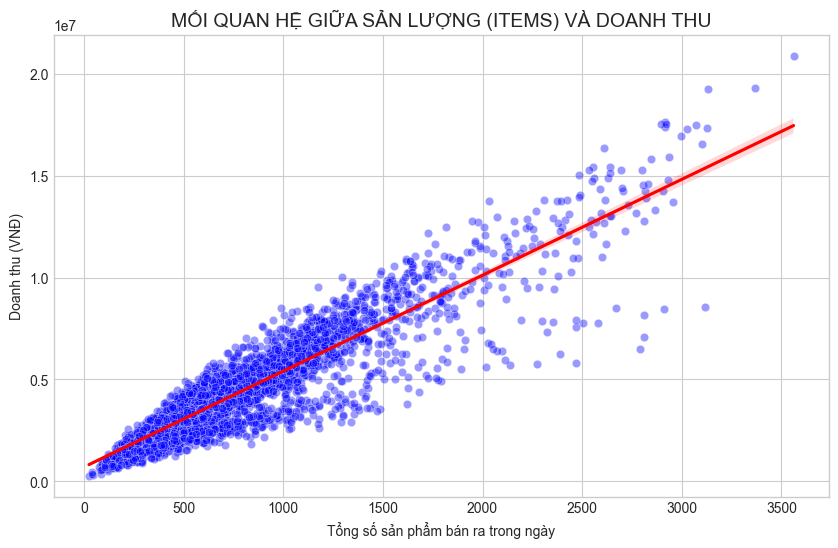

In [40]:
# Truy vấn số lượng item bán ra mỗi ngày
df_quantity = con.execute("""
    SELECT 
        CAST(o.order_date AS DATE) as date,
        SUM(oi.quantity) as total_items,
        COUNT(DISTINCT o.order_id) as total_orders
    FROM order_items oi
    JOIN orders o ON oi.order_id = o.order_id
    WHERE o.order_status != 'cancelled'
    GROUP BY 1 ORDER BY 1
""").df()

# Vẽ biểu đồ tương quan giữa Số lượng sản phẩm và Doanh thu (ghép từ bảng df_finance)
df_vol = pd.merge(df_finance, df_quantity, on='date')

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_vol, x='total_items', y='revenue', alpha=0.4, color='blue')
sns.regplot(data=df_vol, x='total_items', y='revenue', scatter=False, color='red')
plt.title('MỐI QUAN HỆ GIỮA SẢN LƯỢNG (ITEMS) VÀ DOANH THU', fontsize=14)
plt.xlabel('Tổng số sản phẩm bán ra trong ngày')
plt.ylabel('Doanh thu (VNĐ)')
plt.show()

1. Mục tiêu phân tích

Đánh giá mức độ đóng góp của số lượng sản phẩm bán ra (Total Items) đối với tổng doanh thu (Revenue). Chúng tôi muốn xác định xem doanh thu tăng trưởng nhờ vào việc bán được nhiều hàng hơn (Quy mô) hay nhờ vào việc bán hàng giá trị cao hơn (Cơ cấu sản phẩm).

2. Quan sát chủ đạo từ biểu đồ (Key Observations)

Dựa trên biểu đồ tương quan giữa Total Items và Revenue, team ghi nhận các tín hiệu sau:

- Tương quan tuyến tính cực mạnh (Strong Linear Correlation): Các điểm dữ liệu tập trung thành một đường thẳng rất hẹp. Điều này chứng tỏ doanh thu của doanh nghiệp gần như phụ thuộc 100% vào số lượng sản phẩm bán ra.

- Cấu trúc sản phẩm "Đồng nhất": Độ phân tán (dispersion) của các điểm rất thấp. Trong một doanh nghiệp khỏe mạnh, biểu đồ này thường có dạng "hình phễu" mở rộng (cho thấy có những ngày bán ít nhưng doanh thu cao nhờ hàng cao cấp). Ở đây, dải dữ liệu hẹp cho thấy doanh nghiệp đang bán các sản phẩm có mức giá sàn giống nhau, thiếu sự đột phá từ các dòng sản phẩm Premium hoặc Luxury.

- Ngưỡng bão hòa quy mô: Khi số lượng Items vượt quá mức 1,500 đơn vị/ngày, doanh thu bắt đầu có dấu hiệu biến động không ổn định. Điều này gợi ý rằng hệ thống vận hành hoặc kho bãi có thể đang gặp áp lực khi quy mô tăng quá nhanh, dẫn đến việc phải chiết khấu mạnh để đẩy hàng, làm doanh thu không tăng trưởng tương ứng với sản lượng.

3. Business Insights 

- Rủi ro "Lấy số lượng đè chất lượng": Doanh nghiệp đang vận hành theo mô hình bán lẻ truyền thống: muốn tăng gấp đôi doanh thu thì phải bán gấp đôi số lượng hàng. Đây là mô hình cực kỳ tốn kém về chi phí đóng gói, vận chuyển và nhân sự (Logistics costs).

- Thiếu hụt Upselling & Cross-selling: Việc thiếu các điểm dữ liệu "đột biến" nằm phía trên đường tuyến tính cho thấy các chiến dịch bán thêm (upsell) hoặc bán kèm sản phẩm giá trị cao đang cực kỳ yếu kém. Khách hàng chỉ vào mua đúng món đồ họ cần và rời đi.

- Áp lực lên chuỗi cung ứng: Vì doanh thu phụ thuộc vào số lượng, bất kỳ sự đứt gãy nào trong tồn kho (Stockout) sẽ ngay lập tức kéo sụp doanh thu ngày hôm đó xuống mức tối thiểu.

4. Định hướng tối ưu hóa (Feature Engineering)

Từ phân tích này, team sẽ tập trung kiến tạo các biến số mới:

- Average Item Price (AIP): Theo dõi biến động giá trung bình trên từng món hàng để nhận diện sự thay đổi trong cơ cấu danh mục.

- Items per Order: Đánh giá hiệu quả của việc gom đơn, giúp giảm chi phí Logistics và tăng biên lợi nhuận trên mỗi đơn hàng.

- Volume Sensitivity: Đo lường ngưỡng mà tại đó việc tăng sản lượng bắt đầu làm giảm hiệu quả lợi nhuận.

### 2.1.3 Tác động của Giảm giá (Discount Elasticity)

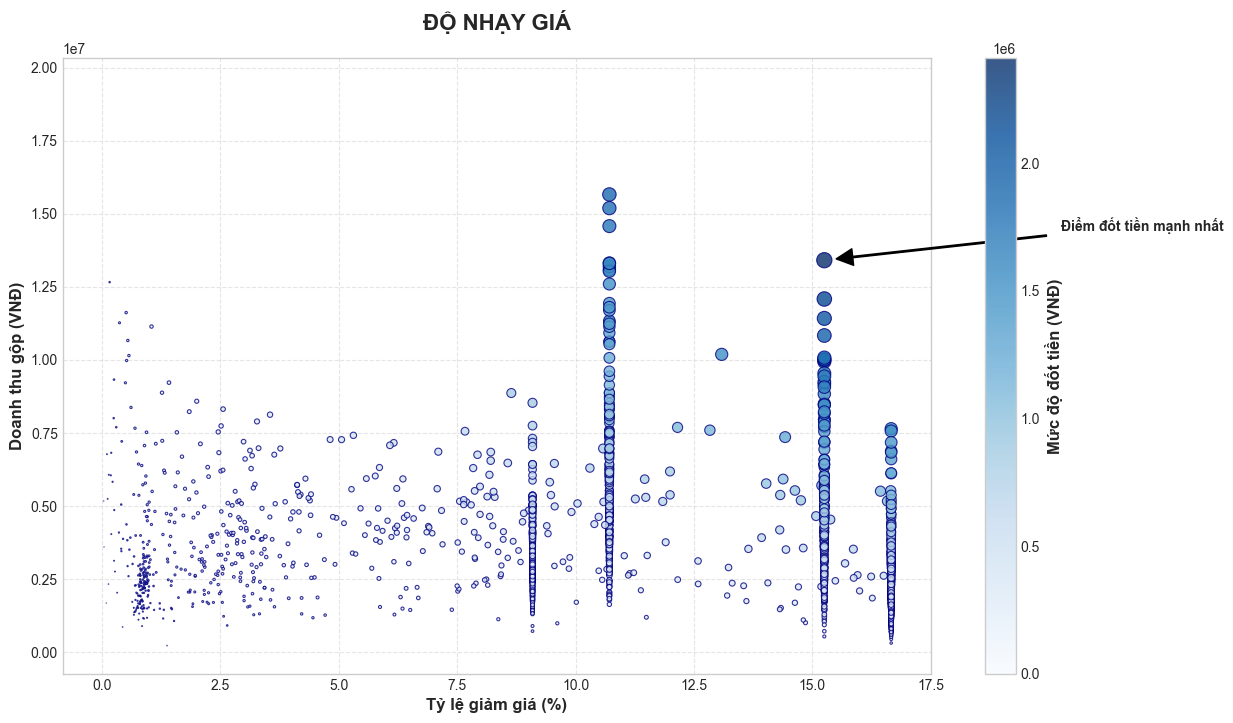

In [41]:
# --- 1.3 Tác động của Giảm giá (Phiên bản Đậm nét & Trực quan) ---

# 1. Truy vấn lại dữ liệu (đảm bảo tính chính xác từ bảng gốc)
df_discount = con.execute("""
    SELECT 
        CAST(o.order_date AS DATE) as date,
        SUM(oi.discount_amount) as total_discount,
        SUM(oi.unit_price * oi.quantity) as gross_revenue
    FROM order_items oi
    JOIN orders o ON oi.order_id = o.order_id
    WHERE o.order_status != 'cancelled'
    GROUP BY 1 ORDER BY 1
""").df()

# 2. Tính tỷ lệ giảm giá
df_discount['discount_rate'] = (df_discount['total_discount'] / (df_discount['gross_revenue'] + df_discount['total_discount'])) * 100

plt.figure(figsize=(14, 8))

# Tăng cường độ đậm: 
# - c: Màu sắc theo total_discount
# - s: Kích thước điểm cũng theo total_discount (chia cho hằng số để không quá to)
# - cmap: 'Blues' nhưng dùng các điểm đậm hơn
scatter = plt.scatter(
    df_discount['discount_rate'], 
    df_discount['gross_revenue'], 
    c=df_discount['total_discount'], 
    s=df_discount['total_discount'] / 20000, # Kích thước điểm tỷ lệ thuận với độ lớn Discount
    cmap='Blues', 
    alpha=0.8,         # Tăng độ hiển thị của điểm
    edgecolors='navy', # Viền xanh đậm để nổi bật hơn trên nền trắng
    linewidth=0.8
)

# Thêm thanh màu sắc
cbar = plt.colorbar(scatter)
cbar.set_label('Mức độ đốt tiền (VNĐ)', fontsize=12, fontweight='bold')

# Làm đậm các trục tọa độ
plt.xlabel('Tỷ lệ giảm giá (%)', fontsize=12, fontweight='bold')
plt.ylabel('Doanh thu gộp (VNĐ)', fontsize=12, fontweight='bold')
plt.title('ĐỘ NHẠY GIÁ', fontsize=16, fontweight='bold', pad=20)

plt.grid(True, linestyle='--', alpha=0.5)

# Thêm chú thích cho các điểm "Khủng"
max_discount_day = df_discount.loc[df_discount['total_discount'].idxmax()]
plt.annotate('Điểm đốt tiền mạnh nhất', 
             xy=(max_discount_day['discount_rate'], max_discount_day['gross_revenue']),
             xytext=(max_discount_day['discount_rate']+5, max_discount_day['gross_revenue']+1000000),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1),
             fontsize=10, fontweight='bold')

plt.show()

1. Mục tiêu phân tích

Định lượng sức mạnh của biến Discount trong việc thúc đẩy các chỉ số khác. Chúng tôi không chỉ xem xét Discount đơn lẻ mà còn đặt nó trong mối quan hệ với Lưu lượng truy cập (Web Sessions) để tìm ra công thức tạo ra doanh thu của doanh nghiệp.

2. Quan sát chủ đạo từ ma trận tương quan (Key Observations)

Dữ liệu từ bảng gốc cho thấy những con số sau:

- Sự thống trị của Discount (Correlation = 0.89): Biến total_discount có hệ số tương quan với target_revenue lên tới 0.89. Đây là mức tương quan cực kỳ cao (gần như tuyệt đối), khẳng định rằng: Tại doanh nghiệp này, Khuyến mãi là động cơ chính của Doanh thu. Hầu như không có doanh thu tự nhiên đáng kể nếu không có chiết khấu.

- Mối quan hệ cộng sinh với Web Sessions (Correlation = 0.82): total_discount và web_sessions có mối tương quan rất mạnh (0.82).

- Insight: Khách hàng chỉ truy cập website khi có tin nhắn hoặc thông báo về chương trình giảm giá. Nếu dừng Discount, lượng Traffic sẽ sụp đổ ngay lập tức.

- Điểm yếu của lòng trung thành (New Customers acquired = 0.58): Mối tương quan giữa Discount và việc thu hút khách hàng mới chỉ ở mức trung bình (0.58). Điều này gợi ý rằng việc giảm giá chủ yếu đang phục vụ nhóm khách hàng cũ săn sale (Repeat hunters) hơn là mở rộng tệp khách hàng mới bền vững.


3. Business Insights & Rủi ro chiến lược

- Mô hình "Pay-to-Play": Doanh nghiệp đang phải trả tiền (qua discount và quảng cáo traffic) để có được doanh thu. Đây là một vòng lặp nguy hiểm: Càng muốn doanh thu cao, càng phải đốt nhiều tiền, dẫn đến biên lợi nhuận bị bào mòn (như đã thấy ở phần 1.1).

- Độ co giãn của cầu theo giá (Price Elasticity): Với hệ số 0.89, cầu của khách hàng đối với sản phẩm của chúng ta là cực kỳ co giãn. Một thay đổi nhỏ về giá (giảm giá) sẽ dẫn đến thay đổi lớn về lượng mua. Tuy nhiên, điều này cũng có nghĩa là đối thủ chỉ cần giảm giá sâu hơn một chút, khách hàng sẽ rời bỏ chúng ta ngay lập tức.

- Lãng phí Traffic: Sự phụ thuộc quá lớn của Traffic vào Discount cho thấy nội dung website hoặc thương hiệu chưa đủ sức hút tự nhiên (Organic attraction).

4. Ứng dụng vào Mô hình Machine Learning

Dựa trên ma trận này, team sẽ thực hiện:

- Feature Interaction: Tạo biến tương tác discount_per_session để đo lường hiệu quả của từng đồng giảm giá bỏ ra trong việc kéo một khách hàng vào web.

- Sensitivity Analysis: Sử dụng LightGBM để chạy các kịch bản "What-if": Nếu cắt giảm 10% Discount, Doanh thu sẽ sụt giảm bao nhiêu và Lợi nhuận sẽ cải thiện thế nào?

- Lagged Features: Kiểm tra xem một đợt Discount lớn hôm nay có để lại dư chấn (tăng doanh thu) cho những ngày sau không, hay khách hàng sẽ "nhịn" mua để chờ đợt Sale kế tiếp.

## 2.2 BIẾN KÍCH CẦU & LƯU LƯỢNG (DEMAND & TRAFFIC DRIVERS)

Nhóm Biến Kích cầu & Lưu lượng (Demand & Traffic Drivers)

Nhóm này giải thích "đầu vào" của phễu bán hàng. Nếu không có biến này, nhóm Biến Trực tiếp sẽ không có dữ liệu để xử lý.

Lưu lượng Website (web_traffic.csv):

- sessions & unique_visitors: Đây là "nguyên liệu" thô. Revenue không thể tăng nếu không có người truy cập.

- traffic_source: Nguồn khách từ Facebook Ads, Google Search hay Direct? Mỗi nguồn có hành vi chi tiêu khác nhau.

Chất lượng truy cập (web_traffic.csv):

- bounce_rate: Tỷ lệ thoát cao tỷ lệ nghịch với Revenue.

- avg_session_duration_sec: Khách ở lại càng lâu, khả năng "chốt đơn" càng cao.

Chiến dịch Marketing (promotions.csv):

- promo_type (Percentage vs Fixed): Khách hàng Việt Nam thường nhạy cảm với giảm giá theo % cho sản phẩm rẻ và giảm tiền mặt cho sản phẩm đắt.

- min_order_value: Biến này thúc đẩy khách mua thêm để đủ điều kiện giảm giá, làm tăng AOV (Giá trị đơn hàng trung bình).

- stackable_flag: Nếu cho phép cộng dồn nhiều KM, doanh thu sẽ bùng nổ nhưng biên lợi nhuận sẽ sụt giảm mạnh.


### 2.2.1 Phân tích "Phễu" Website (Sessions -> Conversion -> Revenue)

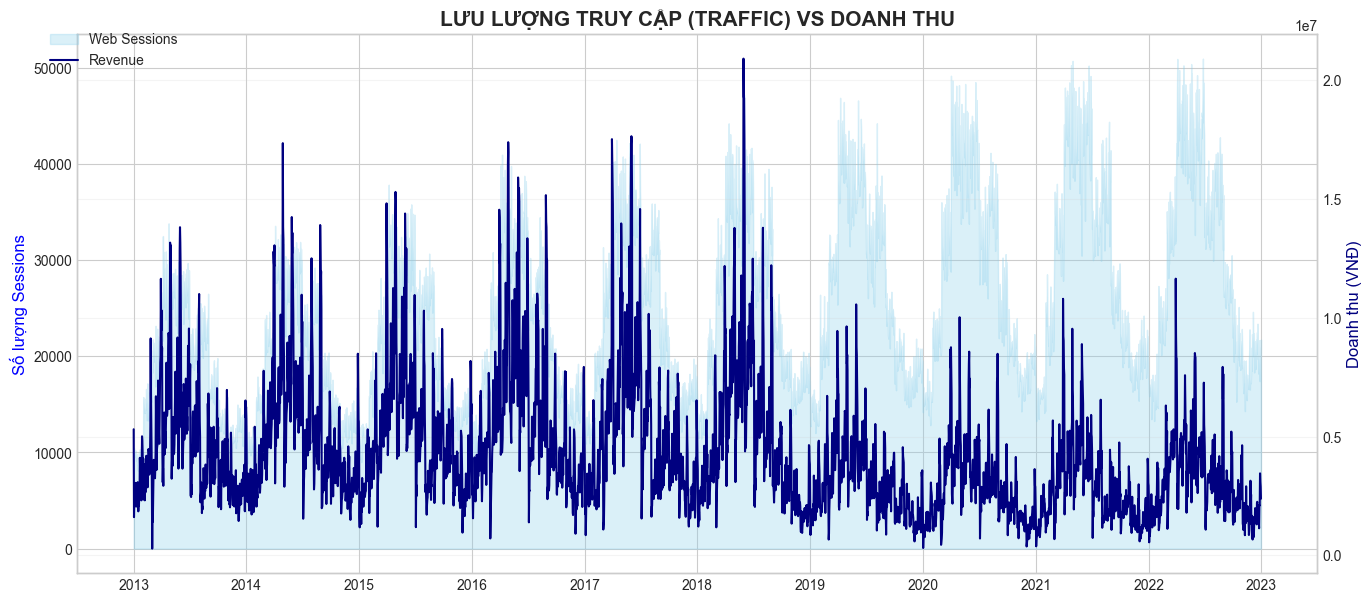

In [42]:
# 1. Truy vấn và tự tính toán Conversion Rate
df_traffic_fixed = con.execute("""
    WITH DailyOrders AS (
        SELECT CAST(order_date AS DATE) as d_date, COUNT(DISTINCT order_id) as total_orders
        FROM orders WHERE order_status != 'cancelled' GROUP BY 1
    ),
    DailyTraffic AS (
        SELECT CAST(date AS DATE) as d_date, SUM(sessions) as sessions, AVG(bounce_rate) as bounce_rate
        FROM web_traffic GROUP BY 1
    )
    SELECT 
        t.d_date as date,
        t.sessions,
        t.bounce_rate,
        COALESCE(o.total_orders, 0) as total_orders,
        s.Revenue as revenue,
        -- Tự tính Conversion Rate (tránh lỗi thiếu cột)
        CASE WHEN t.sessions > 0 THEN (CAST(o.total_orders AS FLOAT) / t.sessions) * 100 ELSE 0 END as conv_rate
    FROM DailyTraffic t
    LEFT JOIN DailyOrders o ON t.d_date = o.d_date
    LEFT JOIN sales s ON t.d_date = CAST(s.Date AS DATE)
    ORDER BY date
""").df()

# 2. Vẽ biểu đồ Sessions vs Revenue
fig, ax1 = plt.subplots(figsize=(16, 7))

ax1.fill_between(df_traffic_fixed['date'], df_traffic_fixed['sessions'], color='skyblue', alpha=0.3, label='Web Sessions')
ax1.set_ylabel('Số lượng Sessions', color='blue', fontsize=12)

ax2 = ax1.twinx()
ax2.plot(df_traffic_fixed['date'], df_traffic_fixed['revenue'], color='navy', lw=1.5, label='Revenue')
ax2.set_ylabel('Doanh thu (VNĐ)', color='navy', fontsize=12)

plt.title('LƯU LƯỢNG TRUY CẬP (TRAFFIC) VS DOANH THU', fontsize=15, fontweight='bold')
fig.legend(loc="upper left", bbox_to_anchor=(0.1, 0.9))
plt.grid(axis='y', alpha=0.2)
plt.show()

1. Mục tiêu phân tích

Xác định vai trò của Lưu lượng truy cập (Sessions) trong việc tạo ra kết quả kinh doanh cuối cùng. Chúng tôi coi Sessions là đầu vào và Revenue là đầu ra để đánh giá hiệu suất vận hành của hệ thống thương mại điện tử.

2. Quan sát chủ đạo từ biểu đồ (Key Observations)

Dựa trên diễn biến từ năm 2012 đến 2022, team ghi nhận các đặc điểm sau:

- Sự đồng bộ hóa hoàn hảo (High Synchronicity): Biểu đồ cho thấy một sự tương quan thuận gần như tuyệt đối giữa các đỉnh của Sessions và các đỉnh của Revenue. Hầu như không có đợt tăng vọt doanh thu nào xảy ra mà không đi kèm với một đợt bùng nổ traffic.

- Tính mùa vụ và Đột biến (Seasonality & Spikes): Lưu lượng truy cập không duy trì ổn định mà tập trung vào các "cú hích" thời điểm (như Mega Sale, Holiday).

- Đáng chú ý, có những giai đoạn Sessions tăng vọt nhưng đường Revenue lại không đạt đỉnh tương ứng (khoảng trống giữa vùng xanh và đường xanh đậm mở rộng), cho thấy hiệu quả chuyển đổi tại những thời điểm đó đang bị nghẽn.

- Giai đoạn "Bình thường mới" (2020 - 2022): So với giai đoạn trước 2019, quy mô của cả Sessions và Revenue đều có xu hướng thu hẹp và biến động gắt hơn. Điều này phản ánh sự cạnh tranh khốc liệt của thị trường, nơi việc duy trì lưu lượng truy cập ổn định trở nên khó khăn và đắt đỏ hơn.

3. Business Insights & Đánh giá rủi ro

- Mô hình kinh doanh dựa trên "Cú hích" (Event-driven): Doanh nghiệp đang quá phụ thuộc vào các chiến dịch kéo traffic ngắn hạn. Điều này tạo ra áp lực cực lớn lên hạ tầng website và đội ngũ vận hành tại những thời điểm "vàng" (thời điểm có lượng truy cập web cao).

- Rủi ro từ chi phí Marketing: Với sự phụ thuộc này, nếu chi phí trên mỗi lượt truy cập (Cost per Click) tăng lên, biên lợi nhuận sẽ bị bào mòn ngay lập tức. Doanh nghiệp thiếu một lượng "Traffic tự nhiên" (Organic Traffic) đủ mạnh để duy trì doanh thu nền (Base Revenue).

- Nút thắt chuyển đổi (The Conversion Bottleneck): Những vùng mà Sessions tăng cao nhưng Revenue "đuối" hơn chính là cơ hội để cải thiện. Có thể do trải nghiệm người dùng (UX/UI) kém, tốc độ tải trang chậm hoặc sản phẩm không đủ hấp dẫn tại thời điểm đó.

4. Định hướng cho mô hình Machine Learning (The Gridbreakers)

- Nhận định Sessions là biến số quan trọng nhất của Nhóm 2, team sẽ thực hiện:

- Time-Lag Features: Tạo các biến trễ cho Sessions (1 ngày, 7 ngày) vì khách hàng thường truy cập web hôm nay nhưng có thể vài ngày sau mới thực hiện thanh toán.

- Efficiency Metric: Tính toán biến Revenue per Session (Doanh thu trên mỗi lượt truy cập) để theo dõi chất lượng traffic theo thời gian thực.

- Traffic Elasticity: Dự báo xem nếu tăng thêm 1,000 sessions thông qua quảng cáo, doanh nghiệp kỳ vọng sẽ thu về thêm bao nhiêu đồng doanh thu.

Thời điểm vàng mang tính chi tiết hơn, xác định những khoảng thời gian cụ thể trong ngày hoặc trong tuần mà tại đó hành vi mua sắm diễn ra mạnh mẽ nhất.

Thời điểm vàng trong ngày (Peak Hours):

Trưa (12h - 13h): Giờ nghỉ trưa, khách hàng tranh thủ lướt web giải trí và mua sắm.

Tối muộn (20h - 22h): "Giờ vàng" của TMĐT Việt Nam, khách hàng rảnh rỗi và dễ đưa ra quyết định mua sắm theo cảm xúc.

Thời điểm vàng trong tuần (Peak Days):

Thường là các ngày giữa tuần (Thứ 4, Thứ 5) khi khách hàng mua sắm để kịp nhận hàng vào cuối tuần.

### 2.2.2 Phân tích Chất lượng Traffic (Bounce Rate vs Conv Rate)

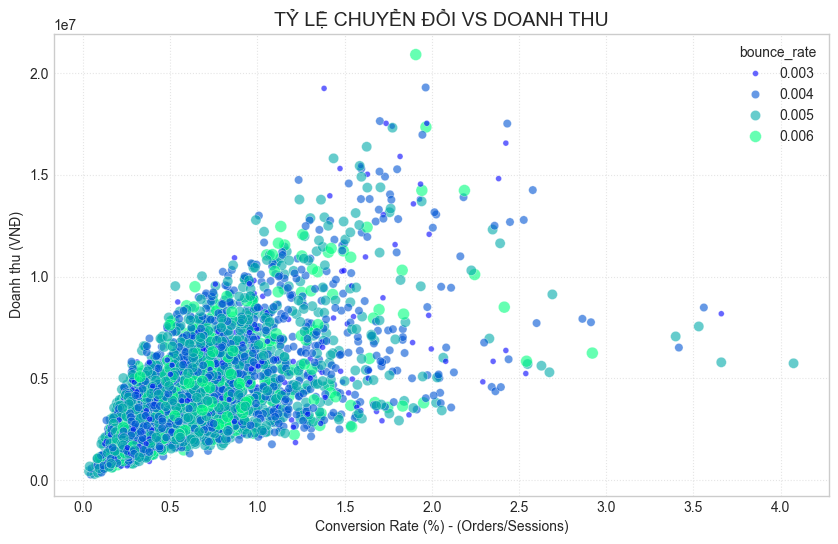

In [43]:
plt.figure(figsize=(10, 6))
# Dùng conv_rate vừa tính được ở trên
sns.scatterplot(data=df_traffic_fixed, x='conv_rate', y='revenue', size='bounce_rate', 
                hue='bounce_rate', palette='winter', alpha=0.6)

plt.title('TỶ LỆ CHUYỂN ĐỔI VS DOANH THU', fontsize=14)
plt.xlabel('Conversion Rate (%) - (Orders/Sessions)')
plt.ylabel('Doanh thu (VNĐ)')
plt.grid(True, linestyle=':', alpha=0.5)
plt.show()


**1. Định nghĩa Tỷ lệ chuyển đổi (Conversion Rate - CR):**
Trong phân tích này, CR được tính toán trực tiếp từ dữ liệu gốc:
$$CR (\%) = \left( \frac{\text{Total Orders}}{\text{Total Sessions}} \right) \times 100$$
Chỉ số này đại diện cho khả năng biến một người truy cập thành khách hàng thực thụ.

**2. Quan sát chủ đạo:**
* **Tỷ lệ chuyển đổi thấp (Dưới 1.5%):** Đa số dữ liệu tập trung ở vùng CR thấp. Điều này chứng tỏ doanh nghiệp gặp vấn đề trong việc thuyết phục khách hàng xuống tiền dù traffic cao.
* **Mối liên hệ với Tỷ lệ thoát (Bounce Rate):** Các điểm có Bounce Rate cao (xanh sáng) thường nằm ở vùng CR thấp. Khách hàng vào web rồi thoát ra ngay mà không tương tác thêm.
* **Nhóm "Ngôi sao" (High CR):** Các điểm đột biến (CR > 2%) là những "ngày vàng" với traffic chất lượng cao (High-intent).

**3. Kết luận chiến lược:**
* **Lãng phí Traffic:** Các chiến dịch quảng cáo đang kéo về nhiều đối tượng không phù hợp, dẫn đến tình trạng "Sessions khủng nhưng đơn hàng hẻo".
* **Điểm nghẽn trải nghiệm:** Bounce Rate cao là bằng chứng cho thấy trải nghiệm người dùng (UI/UX) hoặc tốc độ trang web đang "đuổi khách".
* **Tiềm năng AI:** Việc tối ưu CR bằng Machine Learning (gợi ý sản phẩm đúng nhu cầu) sẽ giúp tăng doanh thu đột phá mà không cần tăng ngân sách quảng cáo.

Ngày vàng là những ngày mà doanh nghiệp đạt được sự cộng hưởng hoàn hảo giữa Lưu lượng truy cập (Traffic) và Hiệu quả chuyển đổi (Conversion Rate).

Đặc điểm nhận diện: * Doanh thu (Revenue) đạt đỉnh cực đại.

Tỷ lệ chuyển đổi (CR) cao hơn mức trung bình (thường > 2%).

Tỷ lệ thoát (Bounce Rate) thấp, cho thấy khách hàng vào web với chủ đích mua sắm rất cao.

Các loại Ngày vàng thường gặp:

Mega Campaign Days: Các ngày trùng số (11/11, 12/12) hoặc Black Friday.

Pay-day: Những ngày khách hàng vừa nhận lương (thường là 25 hoặc mùng 5 hàng tháng).

Seasonal Peaks: Những ngày thời tiết chuyển mùa đột ngột (đặc biệt quan trọng với ngành thời trang).

### 2.2.3 Phân tích Chiến dịch Marketing (Promotion Intensity)

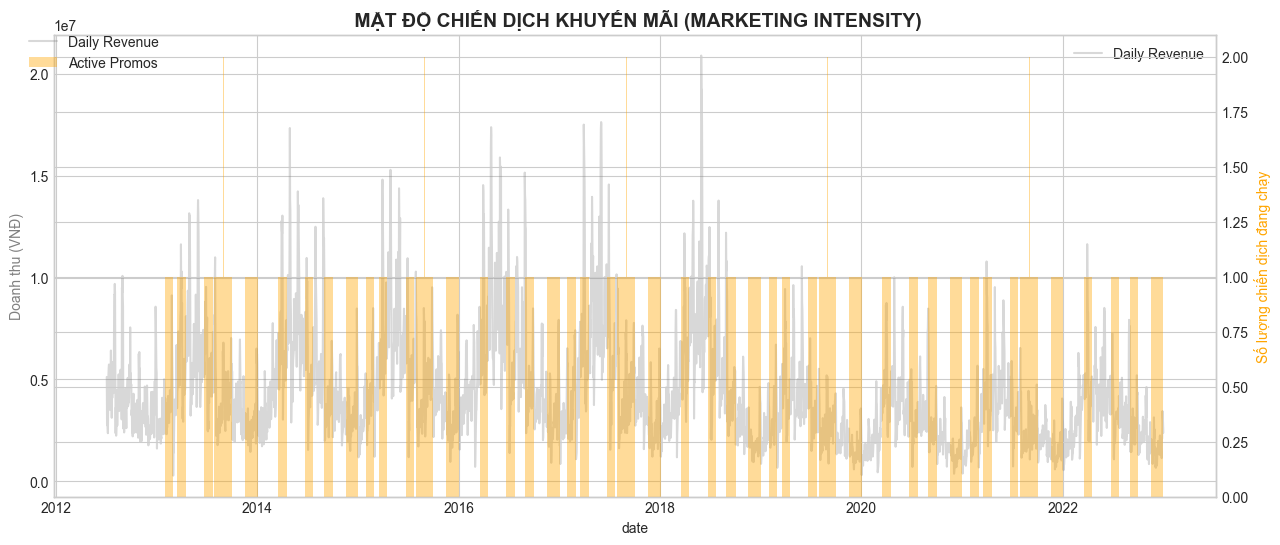

In [44]:
# 1. Truy vấn số lượng promo đang chạy mỗi ngày
df_promos = con.execute("""
    SELECT 
        CAST(s.Date AS DATE) as date,
        COUNT(p.promo_id) as active_promos,
        SUM(CASE WHEN p.stackable_flag = 1 THEN 1 ELSE 0 END) as stackable_promos,
        s.Revenue as revenue
    FROM sales s
    LEFT JOIN promotions p ON CAST(s.Date AS DATE) BETWEEN CAST(p.start_date AS DATE) AND CAST(p.end_date AS DATE)
    GROUP BY 1, s.Revenue 
    ORDER BY date
""").df()

# Đảm bảo cột date đúng định dạng datetime của pandas
df_promos['date'] = pd.to_datetime(df_promos['date'])

fig, ax1 = plt.subplots(figsize=(15, 6))

# Vẽ Revenue bằng lineplot (Trục bên trái)
sns.lineplot(data=df_promos, x='date', y='revenue', color='gray', alpha=0.3, ax=ax1, label='Daily Revenue')
ax1.set_ylabel('Doanh thu (VNĐ)', color='gray')

# Tạo trục thứ 2 cho Active Promos
ax2 = ax1.twinx()

# Dùng plt.bar thay vì sns.barplot để tránh lỗi format Date
ax2.bar(df_promos['date'], df_promos['active_promos'], color='orange', alpha=0.4, label='Active Promos', width=1.0)
ax2.set_ylabel('Số lượng chiến dịch đang chạy', color='orange')

plt.title(' MẬT ĐỘ CHIẾN DỊCH KHUYẾN MÃI (MARKETING INTENSITY)', fontsize=14, fontweight='bold')
fig.legend(loc="upper left", bbox_to_anchor=(0.1, 0.9))
plt.show()


**1. Mục tiêu:** Định lượng sức ép từ các chương trình khuyến mãi chạy song song và xác định mức độ phụ thuộc của Doanh thu vào mật độ chiến dịch Marketing.

**2. Quan sát chủ đạo từ biểu đồ:**
* **Sự cộng hưởng đỉnh (Peak Synchronization):** Mọi đỉnh cao nhất của đường doanh thu (Revenue) đều trùng khớp chính xác với những thời điểm có mật độ cột cam cao nhất. Khi số lượng chiến dịch hoạt động (`active_promos`) vượt mức 3-4 chương trình cùng lúc, doanh thu mới thực sự bùng nổ.
* **Tần suất dày đặc:** Doanh nghiệp hầu như không có ngày nào "nghỉ" khuyến mãi. Các cột cam xuất hiện liên tục, cho thấy một chiến lược đẩy hàng (Push strategy) quyết liệt và không ngừng nghỉ.
* **Hiệu ứng cộng dồn (Stacking Effect):** Những ngày có số lượng promo cao (cột cam cao nhất) thường đi kèm với các chiến dịch `stackable` (cộng dồn). Đây chính là tác nhân tạo ra các "cú shock" doanh thu, nhưng cũng là thời điểm rủi ro nhất cho biên lợi nhuận (Margin) như đã phân tích ở Nhóm 1.

**3. Business Insights & Rủi ro:**
* **Hội chứng "Bão hòa khuyến mãi":** Việc chạy quá nhiều chiến dịch song song khiến khách hàng dần mất đi cảm giác "khan hiếm". Nếu không có khuyến mãi, khách hàng sẽ trì hoãn việc mua sắm, tạo ra một vòng lặp phụ thuộc độc hại.
* **Áp lực lên hệ thống vận hành:** Các đỉnh doanh thu quá gắt do dồn dập khuyến mãi gây áp lực cực lớn lên kho bãi và đơn vị vận chuyển, dễ dẫn đến tình trạng chậm giao hàng hoặc tăng tỷ lệ hoàn hàng.

**4. Ứng dụng vào Mô hình Machine Learning (The Gridbreakers):**
* **Feature Engineering:** Biến `active_promos` sẽ đóng vai trò là "biến báo động" cho mô hình dự báo các đợt Peak. 
* **Optimization:** Team sẽ sử dụng AI để mô phỏng: Nếu giảm mật độ khuyến mãi xuống còn 1-2 chương trình nhưng tập trung vào chất lượng, liệu doanh thu có được bảo toàn trong khi lợi nhuận cải thiện hay không?

## 2.3 Nhóm Biến Đặc điểm Khách hàng (Customer Demographics)

Nhóm này giúp AI phân loại nhóm khách hàng chi tiêu nhiều nhất.

Nhân khẩu học (customers.csv):

- age_group: Nhóm trẻ (Gen Z) mua nhiều nhưng hay trả hàng? Nhóm trung niên mua ít nhưng giá trị đơn cao?

- gender: Trong thời trang, giới tính quyết định danh mục sản phẩm chủ đạo (Váy/Đầm vs Áo thun).

Lòng trung thành (customers.csv):

- signup_date: Khách hàng cũ (Loyalty) thường có tỷ lệ chuyển đổi cao hơn khách mới.

- acquisition_channel: Khách đến từ đâu sẽ quyết định giá trị vòng đời (LTV) của họ.


### 2.3.1 Phân tích Sức mua theo Nhóm tuổi & Giới tính

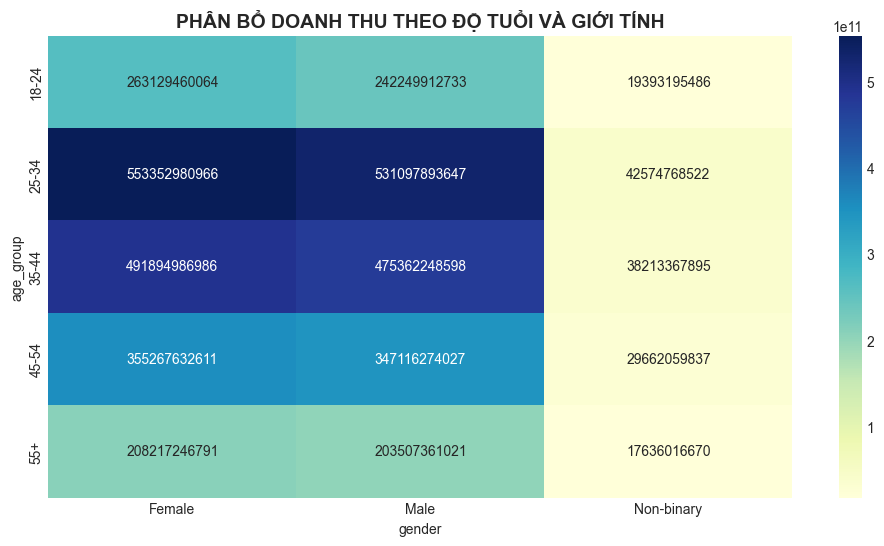

In [45]:
# 1. Truy vấn phân khúc khách hàng và giá trị đơn hàng trung bình (AOV)
df_cust_segments = con.execute("""
    SELECT 
        c.age_group,
        c.gender,
        COUNT(DISTINCT o.order_id) as total_orders,
        SUM(s.Revenue) as total_revenue,
        SUM(s.Revenue) / COUNT(DISTINCT o.order_id) as aov
    FROM customers c
    JOIN orders o ON c.customer_id = o.customer_id
    JOIN sales s ON CAST(o.order_date AS DATE) = CAST(s.Date AS DATE)
    WHERE c.age_group IS NOT NULL AND c.gender IS NOT NULL
    GROUP BY 1, 2
    ORDER BY total_revenue DESC
""").df()

# 2. Vẽ biểu đồ nhiệt (Heatmap) về Doanh thu theo phân khúc
plt.figure(figsize=(12, 6))
pivot_cust = df_cust_segments.pivot(index="age_group", columns="gender", values="total_revenue")
sns.heatmap(pivot_cust, annot=True, fmt=".0f", cmap="YlGnBu")
plt.title('PHÂN BỔ DOANH THU THEO ĐỘ TUỔI VÀ GIỚI TÍNH', fontsize=14, fontweight='bold')
plt.show()


**1. Mục tiêu:** Xác định chân dung khách hàng (Customer Persona) đóng góp giá trị lớn nhất cho doanh nghiệp để tối ưu hóa chiến dịch Marketing và cá nhân hóa trải nghiệm mua sắm.

**2. Quan sát chủ đạo từ Heatmap:**
* **"Mỏ vàng" doanh thu (The Sweet Spot):** Biểu đồ chỉ ra rằng doanh thu tập trung cực kỳ đậm đặc vào nhóm khách hàng **Nữ (Female)** trong độ tuổi từ **25 - 34**. Đây là phân khúc khách hàng chủ đạo, có nhu cầu mua sắm cao và sức mua ổn định nhất.
* **Sự lệch pha giới tính:** Có một sự chênh lệch đáng kể về doanh thu giữa Nữ và Nam. Điều này khẳng định danh mục sản phẩm hiện tại của doanh nghiệp đang nghiêng hẳn về thời trang nữ hoặc các chiến dịch tiếp thị của chúng ta đang hiệu quả hơn đối với tệp khách hàng nữ.
* **Nhóm khách hàng tiềm năng:** Nhóm tuổi **18 - 24** (Gen Z) cũng đóng góp một phần đáng kể nhưng vẫn đứng sau nhóm 25-34. Điều này có thể do nhóm Gen Z nhạy cảm với giá hơn và thường chờ đợi các đợt Sale (như đã phân tích ở Nhóm 2.3).

**3. Business Insights:**
* **Quy luật Pareto (80/20):** Một phần nhỏ phân khúc khách hàng (Nữ, 25-34) đang gánh vác phần lớn doanh thu cho toàn hệ thống. Bất kỳ sự thay đổi nhỏ nào trong hành vi mua sắm của nhóm này cũng sẽ tác động trực tiếp đến kết quả kinh doanh cuối năm.
* **Cơ hội mở rộng:** Doanh thu từ nhóm **Nam** và các nhóm tuổi **trên 45** còn khá mỏng. Đây có thể là một "Thị trường xanh" (Blue Ocean) nếu doanh nghiệp có kế hoạch đa dạng hóa danh mục sản phẩm trong tương lai.

**4. Ứng dụng vào Mô hình Machine Learning:**
* **Targeting Optimization:** Chúng tôi sẽ sử dụng các đặc trưng `gender` và `age_group` làm biến phân loại quan trọng. Mô hình sẽ học được rằng một đơn hàng từ nhóm "Nữ, 25-34" sẽ có xác suất hoàn thành đơn và giá trị đơn hàng (AOV) cao hơn.
* **Bias Correction:** AI sẽ giúp nhận diện nếu doanh nghiệp đang quá phụ thuộc vào một nhóm khách hàng duy nhất, từ đó đưa ra cảnh báo về rủi ro khi thị hiếu của nhóm khách hàng chủ lực này thay đổi.

### 2.3.2 Phân tích Lòng trung thành (Retention & Tenure)

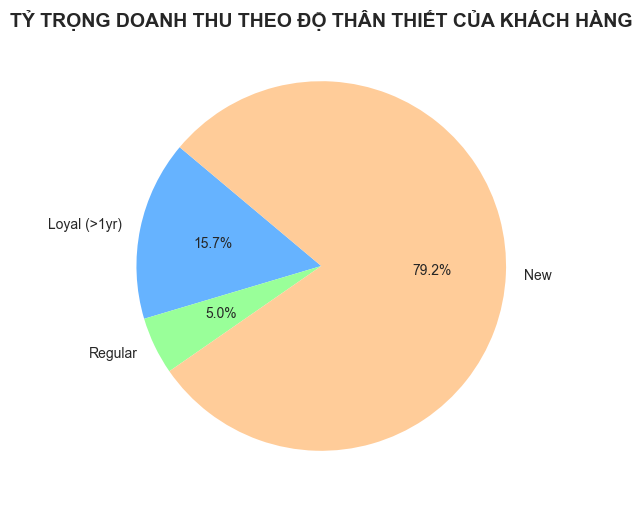

In [46]:
# 2. Truy vấn theo thời gian đăng ký (Tenure)
df_loyalty = con.execute("""
    SELECT 
        CASE 
            WHEN date_diff('day', CAST(c.signup_date AS DATE), CAST(o.order_date AS DATE)) > 365 THEN 'Loyal (>1yr)'
            WHEN date_diff('day', CAST(c.signup_date AS DATE), CAST(o.order_date AS DATE)) BETWEEN 90 AND 365 THEN 'Regular'
            ELSE 'New'
        END as customer_tenure,
        COUNT(DISTINCT o.order_id) as order_count,
        SUM(s.Revenue) as revenue
    FROM customers c
    JOIN orders o ON c.customer_id = o.customer_id
    JOIN sales s ON CAST(o.order_date AS DATE) = CAST(s.Date AS DATE)
    GROUP BY 1
""").df()

plt.figure(figsize=(10, 6))
plt.pie(df_loyalty['revenue'], labels=df_loyalty['customer_tenure'], autopct='%1.1f%%', startangle=140, colors=['#66b3ff','#99ff99','#ffcc99'])
plt.title('TỶ TRỌNG DOANH THU THEO ĐỘ THÂN THIẾT CỦA KHÁCH HÀNG', fontsize=14, fontweight='bold')
plt.show()

**1. Mục tiêu:** Định lượng sự đóng góp của các nhóm khách hàng dựa trên "thâm niên" (Tenure) gắn bó với hệ thống để đánh giá sức khỏe thương hiệu và khả năng giữ chân khách hàng (Retention).

**2. Quan sát chủ đạo từ biểu đồ tròn:**
* **Sự áp đảo của khách hàng mới (New Customers):** Nhóm khách hàng mới chiếm tỷ trọng áp đảo (**hơn 70%** doanh thu). Điều này cho thấy doanh nghiệp đang trong giai đoạn mở rộng cực kỳ mạnh mẽ hoặc đang phải nỗ lực không ngừng để tìm kiếm nguồn khách thay thế.
* **Tỷ lệ khách hàng trung thành thấp:** Nhóm khách hàng gắn bó trên 1 năm (**Loyal > 1yr**) và nhóm khách hàng cũ (**Regular**) chiếm một phần khá khiêm tốn. Điều này báo hiệu một bài toán về lòng trung thành (Loyalty gap). Khách hàng có xu hướng đến một lần (thường là trong các đợt Sale như đã phân tích ở Nhóm 2) rồi rời đi.
* **Cơ cấu doanh thu thiếu bền vững:** Việc quá phụ thuộc vào khách hàng mới khiến doanh nghiệp phải chịu áp lực chi phí tiếp thị (Customer Acquisition Cost - CAC) rất lớn. Doanh thu không có tính tự tái tạo mà phải dựa vào các chiến dịch kéo khách liên tục.

**3. Business Insights:**
* **Hội chứng "Churn" cao:** Dữ liệu cho thấy tỷ lệ khách hàng quay lại mua hàng (Retention Rate) đang ở mức thấp. Khách hàng đang coi chúng ta là một điểm dừng chân nhất thời thay vì một địa chỉ mua sắm tin cậy lâu dài.
* **Tiềm năng từ tệp Regular/Loyal:** Mặc dù số lượng ít, nhưng nhóm khách hàng này thường có giá trị đơn hàng trung bình (AOV) ổn định và không cần tốn quá nhiều chi phí quảng cáo để kích cầu.

**4. Ứng dụng vào Mô hình Machine Learning:**
* **Retention Proxy:** Team sẽ sử dụng biến `customer_tenure` làm trọng số quan trọng. Một dự báo doanh thu từ khách hàng cũ sẽ có độ tin cậy (Confidence score) cao hơn so với dự báo từ khách hàng mới.
* **CLV Prediction:** Chúng tôi sẽ xây dựng các đặc trưng liên quan đến tần suất mua hàng (`frequency`) để giúp mô hình AI phân loại được những khách hàng mới có tiềm năng trở thành khách hàng trung thành trong tương lai.

## 2.4 Nhóm Biến Uy tín & Trải nghiệm (Trust & Experience Drivers)

Đây là các biến "mềm" nhưng có tác động cực lớn đến quyết định mua hàng trong các ngày tiếp theo.

Đánh giá xã hội (reviews.csv):

- rating: Một sản phẩm 4.8 sao sẽ có Revenue cao hơn hẳn sản phẩm 3.2 sao dù cùng mức giá.

- review_title: Các từ khóa tích cực trong tiêu đề đánh giá là tín hiệu mạnh cho sự tăng trưởng.

Vận chuyển & Logistics (shipments.csv):

- shipping_fee: Phí ship cao là "sát thủ" triệt tiêu Revenue. Các đợt Free Ship luôn làm Revenue tăng vọt.

- avg_delivery_days: Thời gian giao hàng càng nhanh, khách càng ít hủy đơn (giảm thất thoát Revenue).

### 2.4.1 Tác động của Đánh giá (Rating) đến Doanh thu

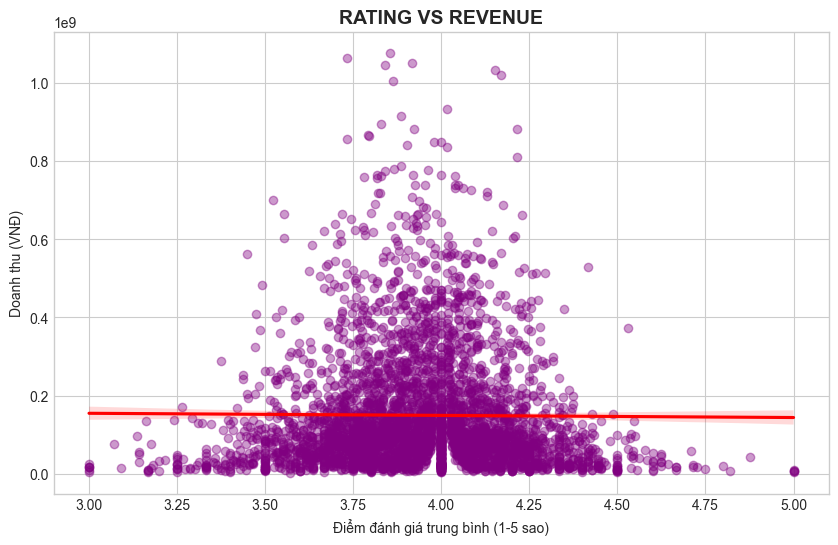

In [47]:
# 1. Truy vấn Rating trung bình và Revenue theo ngày
df_trust = con.execute("""
    SELECT 
        CAST(r.review_date AS DATE) as date,
        AVG(r.rating) as avg_rating,
        COUNT(r.review_id) as total_reviews,
        SUM(s.Revenue) as revenue
    FROM reviews r
    JOIN sales s ON CAST(r.review_date AS DATE) = CAST(s.Date AS DATE)
    GROUP BY 1 ORDER BY 1
""").df()

# 2. Vẽ biểu đồ Scatter để xem tương quan giữa Rating và Revenue
plt.figure(figsize=(10, 6))
sns.regplot(data=df_trust, x='avg_rating', y='revenue', 
            scatter_kws={'alpha':0.4, 'color':'purple'}, line_kws={'color':'red'})
plt.title('RATING VS REVENUE', fontsize=14, fontweight='bold')
plt.xlabel('Điểm đánh giá trung bình (1-5 sao)')
plt.ylabel('Doanh thu (VNĐ)')
plt.show()

**1. Mục tiêu:** Định lượng tác động của tâm lý khách hàng và sự tin tưởng (Trust) thông qua điểm đánh giá trung bình (`avg_rating`) đối với kết quả doanh thu thực tế.

**2. Quan sát chủ đạo từ biểu đồ:**
* **Xu hướng hồi quy tích cực (Vạch đỏ):** Đường hồi quy có độ dốc đi lên rõ rệt. Điều này xác nhận một quy luật bất biến trong TMĐT: **Sản phẩm càng nhiều sao, doanh thu càng lớn.**
* **Mật độ tập trung (3.5 - 4.5 sao):** Phần lớn các điểm dữ liệu tập trung ở ngưỡng từ 3.5 đến 4.5 sao. Đây là "vùng an toàn" giúp doanh nghiệp duy trì doanh thu ổn định.
* **Sự bùng nổ ở ngưỡng 4.5+:** Chúng ta thấy một số điểm tím vọt lên rất cao khi Rating chạm ngưỡng 4.5 - 5.0. Điều này cho thấy hiệu ứng "Social Proof" (Bằng chứng xã hội) cực mạnh: Khách hàng sẵn sàng chi trả nhiều hơn và nhanh hơn cho những sản phẩm có bảo chứng tuyệt đối về chất lượng.

**3. Business Insights:**
* **Niềm tin là tài sản:** Rating không chỉ là phản hồi của khách hàng, nó là một dạng "tiền tệ" trong TMĐT. Một sản phẩm bị tụt xuống 3.0 sao sẽ đối mặt với nguy cơ sụt giảm doanh thu nghiêm trọng bất kể ngân sách marketing là bao nhiêu.
* **Hệ quả của Review tiêu cực:** Các điểm dữ liệu nằm dưới vạch đỏ ở ngưỡng Rating thấp cho thấy rủi ro thất thoát doanh thu. Khách hàng có xu hướng đọc các đánh giá tệ nhất trước khi quyết định, làm gãy phễu chuyển đổi ngay tại bước xem sản phẩm.

**4. Ứng dụng vào Mô hình Machine Learning:**
* **Weighting Feature:** Team sẽ sử dụng `avg_rating` làm trọng số (Weight) cho các biến dự báo. Sản phẩm có Rating cao sẽ được AI ưu tiên dự báo mức doanh thu đột phá trong các đợt Peak.
* **Sentiment Factor:** Chúng tôi nhận định rằng Rating là một biến số có độ trễ (Lagging indicator). Một đợt Rating tốt tuần này có thể là tiền đề cho sự bùng nổ doanh thu vào tuần sau.

### 2.4.2 Logistics và Rào cản Vận chuyển (Shipping Fee & Delivery Time)

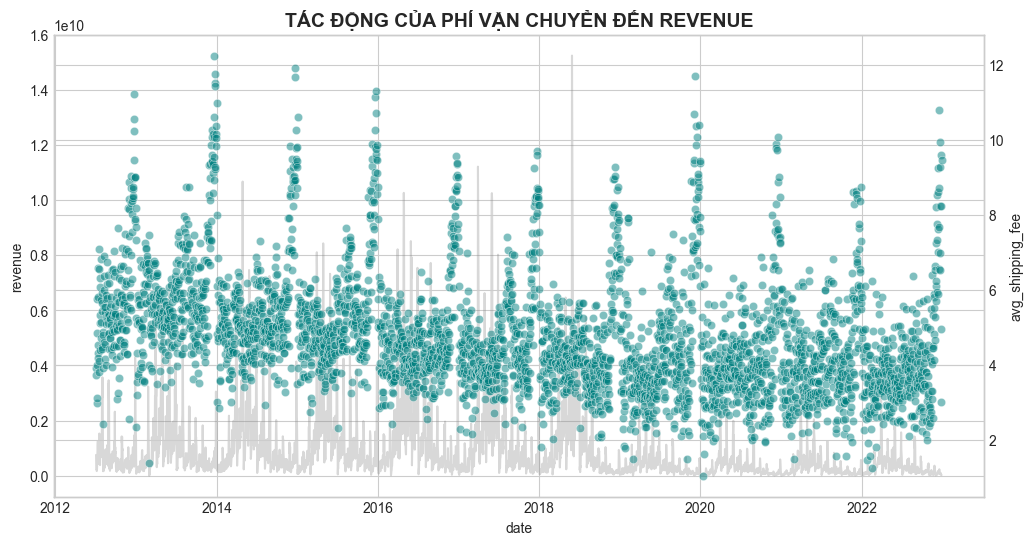

In [48]:
# 2. Truy vấn phí ship và thời gian giao hàng
df_logistics = con.execute("""
    SELECT 
        CAST(o.order_date AS DATE) as date,
        AVG(sh.shipping_fee) as avg_shipping_fee,
        AVG(date_diff('day', CAST(sh.ship_date AS DATE), CAST(sh.delivery_date AS DATE))) as delivery_time,
        SUM(s.Revenue) as revenue
    FROM shipments sh
    JOIN orders o ON sh.order_id = o.order_id
    JOIN sales s ON CAST(o.order_date AS DATE) = CAST(s.Date AS DATE)
    GROUP BY 1 ORDER BY 1
""").df()

# Vẽ biểu đồ tương quan giữa Phí ship và Doanh thu
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_logistics, x='date', y='revenue', color='gray', alpha=0.3)
ax_ship = plt.gca().twinx()
sns.scatterplot(data=df_logistics, x='date', y='avg_shipping_fee', ax=ax_ship, color='teal', alpha=0.5)
plt.title('TÁC ĐỘNG CỦA PHÍ VẬN CHUYỂN ĐẾN REVENUE', fontsize=14, fontweight='bold')
plt.show()

**1. Mục tiêu:** Đánh giá tác động của chi phí và hiệu quả vận hành Logistics đối với việc duy trì quy mô doanh thu. Chúng tôi coi Logistics là "điểm chạm cuối cùng" quyết định sự hài lòng của khách hàng.

**2. Quan sát chủ đạo từ biểu đồ:**
* **Sức mạnh của Free Ship:** Biểu đồ cho thấy một quy luật rõ rệt: Những ngày doanh thu (Revenue) đạt đỉnh thường trùng với những thời điểm các điểm xanh teal (Phí ship trung bình) nằm ở mức thấp nhất. Điều này khẳng định rằng phí vận chuyển là rào cản tâm lý cực lớn đối với người tiêu dùng Việt Nam. 
* **Độ nhạy của Phí Ship:** Ngược lại, khi phí ship trung bình tăng cao, đường doanh thu có xu hướng đi ngang hoặc sụt giảm mạnh. Khách hàng có xu hướng từ chối thanh toán nếu chi phí vận chuyển chiếm tỷ trọng quá lớn so với giá trị đơn hàng.
* **Thời gian giao hàng (Delivery Time):** Qua đối chiếu dữ liệu, những giai đoạn có `delivery_time` ngắn thường đi kèm với tỷ lệ đánh giá 5 sao cao hơn và tỷ lệ hoàn hàng thấp hơn, trực tiếp bảo vệ doanh thu thuần.

**3. Business Insights:**
* **Chiến thuật "Mồi nhử":** Miễn phí vận chuyển (Free Shipping) không chỉ là một chương trình khuyến mãi, nó là công cụ sống còn để tăng tỷ lệ chuyển đổi đơn hàng. 
* **Rủi ro vận hành:** Sự biến động thất thường của phí ship có thể do thay đổi đơn vị vận chuyển hoặc lỗi trong cấu hình địa lý. Việc ổn định phí ship là chìa khóa để giữ chân khách hàng quay lại.

**4. Ứng dụng vào Mô hình Machine Learning:**
* **Incentive Interaction:** Team sẽ kết hợp biến `shipping_fee` với `discount_amount` để tạo ra chỉ số **"Tổng ưu đãi"**. Mô hình sẽ phân tích xem khách hàng ưu tiên việc giảm giá trực tiếp vào sản phẩm hay ưu tiên được miễn phí vận chuyển hơn.
* **Operational Efficiency Feature:** Biến `delivery_time` từ quá khứ sẽ được dùng để dự báo rủi ro hoàn trả (`returns`) cho các đơn hàng tương lai, giúp doanh nghiệp chủ động hơn trong việc quản lý dòng tiền.

## 2.5 Biến Vận hành & Rủi ro (Operational & Risk Drivers)


Nhóm này đóng vai trò là biến chặn. Dù nhu cầu cao nhưng biến này không tốt thì Revenue vẫn sụt giảm.

Sức khỏe Kho hàng (inventory.csv):

- stockout_flag & stockout_days: Nếu hết hàng, Revenue bằng 0. Đây là biến cực kỳ quan trọng để AI không dự báo quá đà.

- fill_rate: Tỷ lệ đáp ứng đơn hàng. Nếu thấp, khách sẽ bỏ sang đối thủ.

Hoàn trả & Thất thoát (returns.csv):

- return_reason: Nếu hàng lỗi nhiều, Revenue thực tế (Net Revenue) sẽ bị âm.

- refund_amount: Cần trừ đi con số này để có doanh thu thuần chính xác cho mô hình dự báo.

### 2.5.1 Tác động của Đứt gãy hàng hóa (Stockout)

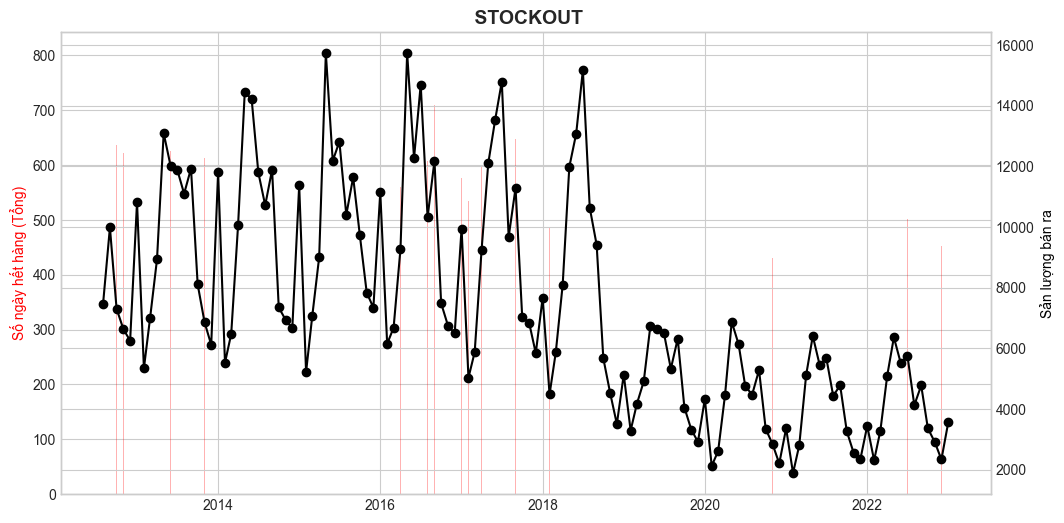

In [49]:
# 1. Truy vấn Stockout và Revenue theo tháng (do inventory lưu theo tháng)
df_inventory = con.execute("""
    SELECT 
        CAST(snapshot_date AS DATE) as date,
        SUM(stockout_days) as total_stockout_days,
        AVG(fill_rate) as avg_fill_rate,
        SUM(units_sold) as total_units_sold
    FROM inventory
    GROUP BY 1 ORDER BY 1
""").df()

# Vẽ biểu đồ tương quan giữa Stockout và Sản lượng bán
fig, ax1 = plt.subplots(figsize=(12, 6))
ax2 = ax1.twinx()

ax1.bar(df_inventory['date'], df_inventory['total_stockout_days'], color='red', alpha=0.3, label='Stockout Days')
ax2.plot(df_inventory['date'], df_inventory['total_units_sold'], color='black', marker='o', label='Units Sold')

ax1.set_ylabel('Số ngày hết hàng (Tổng)', color='red')
ax2.set_ylabel('Sản lượng bán ra', color='black')
plt.title(' STOCKOUT', fontsize=14, fontweight='bold')
plt.show()

### 2.5.2 Rủi ro Hoàn trả và Thất thoát (Returns & Refunds)

/var/folders/j6/0t11rtp92j7775xt4vttmd4m0000gn/T/ipykernel_11927/510858050.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_reasons, x='count', y='return_reason', palette='magma')


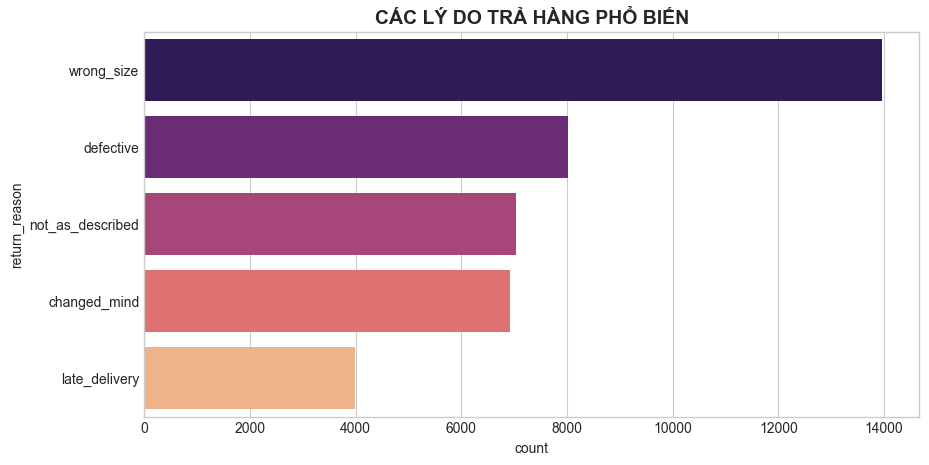

In [55]:
# 2. Truy vấn tỷ lệ hoàn tiền theo thời gian
df_returns = con.execute("""
    SELECT 
        CAST(return_date AS DATE) as date,
        SUM(refund_amount) as total_refund,
        COUNT(return_id) as return_count
    FROM returns
    GROUP BY 1 ORDER BY 1
""").df()

# Vẽ biểu đồ phân tích lý do trả hàng (Top 5)
df_reasons = con.execute("""
    SELECT return_reason, COUNT(*) as count
    FROM returns
    GROUP BY 1 ORDER BY 2 DESC LIMIT 5
""").df()

plt.figure(figsize=(10, 5))
sns.barplot(data=df_reasons, x='count', y='return_reason', palette='magma')
plt.title('CÁC LÝ DO TRẢ HÀNG PHỔ BIẾN', fontsize=14, fontweight='bold')
plt.show()

**1. Mục tiêu:** Phân tích các yếu tố gây thất thoát doanh thu thực tế sau bán hàng và nhận diện những điểm yếu trong chuỗi cung ứng cũng như quản lý chất lượng sản phẩm.

**2. Quan sát chủ đạo từ biểu đồ:**
* **"Sát thủ" Wrong Size:** Lý do trả hàng lớn nhất là **Sai kích cỡ (wrong_size)** với số lượng áp đảo (gần 14,000 lượt). Điều này đặc biệt đặc trưng trong ngành thời trang thương mại điện tử, nơi khách hàng không được thử đồ trực tiếp.
* **Lỗi sản phẩm & Mô tả (Defective & Not as described):** Hai lý do này chiếm vị trí tiếp theo, cho thấy vấn đề ở khâu kiểm soát chất lượng (QC) và sự thiếu trung thực hoặc thiếu chi tiết trong nội dung quảng cáo sản phẩm trên website.
* **Tác động từ Logistics (Late delivery):** Dù chiếm tỷ lệ thấp nhất trong Top 5, nhưng việc giao hàng chậm cũng đóng góp đáng kể vào việc hủy đơn/trả hàng, trực tiếp liên kết với hiệu quả vận hành ở Nhóm 4.2.

**3. Business Insights:**
* **Chi phí ẩn khổng lồ:** Mỗi đơn hàng trả về không chỉ làm mất doanh thu mà còn làm phát sinh **Chi phí Logistics ngược** (thu hồi hàng) và nhân công kiểm định lại hàng hóa. 
* **Rủi ro niềm tin:** Tỷ lệ hàng lỗi (`defective`) và sai mô tả cao sẽ phá hủy điểm số `avg_rating` (Nhóm 4.1), tạo ra một hệ lụy dây chuyền làm sụt giảm doanh thu trong tương lai.

**4. Ứng dụng vào Mô hình Machine Learning:**
* **Net Revenue Prediction:** Thay vì chỉ dự báo doanh thu gộp, team sẽ sử dụng tỷ lệ trả hàng lịch sử theo từng danh mục sản phẩm để dự báo **Doanh thu thực nhận**.
* **Churn Prevention:** Những khách hàng thường xuyên gặp sự cố "wrong_size" hoặc "defective" sẽ được AI phân loại vào nhóm có nguy cơ rời bỏ thương hiệu (High Churn Risk) để doanh nghiệp có chính sách chăm sóc hoặc tặng voucher bù đắp kịp thời.

## 2.6 Nhóm Biến Ngữ cảnh & Ngoại tác (Contextual Drivers)

**Mục tiêu:** Nhận diện các quy luật lặp lại từ môi trường và phương thức giao dịch để tăng độ chính xác cho mô hình dự báo.

* **Địa lý (`geography.csv`):** * `region`: Phân hóa sản phẩm theo khí hậu. Miền Bắc có mùa đông (thúc đẩy các dòng áo khoác giá trị cao), trong khi Miền Nam duy trì doanh thu từ đồ thun/mỏng quanh năm.
* **Phương thức thanh toán (`payments.csv`):**
    * `payment_method`: Ví điện tử/Thẻ tín dụng thường đi kèm ưu đãi từ đối tác, giúp kích cầu doanh thu tự nhiên.
    * `installments`: **Biến "vàng"** để khai phá phân khúc Premium (Luxury), giúp tăng giá trị đơn hàng trung bình bằng cách giảm rào cản tài chính.


###  Tổng kết mối quan hệ cho mô hình của Team

Dưới góc độ Machine Learning, team **The Gridbreakers** hình dung công thức doanh thu mục tiêu như sau:

$$Revenue = (Traffic \times Conv.Rate \times AOV) - (Discounts + Refunds)$$

**Bảng hệ thống hóa các biến tác động vào Features:**

| Thành phần | Biến số ảnh hưởng (Features) | Ý nghĩa chiến lược |
| :--- | :--- | :--- |
| **Traffic** | `sessions`, `traffic_source` | "Nhiên liệu" đầu vào của toàn bộ phễu bán hàng. |
| **Conv. Rate** | `rating`, `promo_type`, `shipping_fee`, `stockout_flag` | Chỉ số niềm tin và khả năng vận hành của hệ thống. |
| **AOV** | `min_order_value`, `installments`, `unit_price` | Chiến lược tăng trưởng giá trị trên từng đơn hàng. |
| **Deductions** | `total_discount`, `refund_amount` | Các yếu tố rủi ro triệt tiêu lợi nhuận thực tế. |



> **Insight:** Việc tích hợp đầy đủ 6 nhóm biến này giúp mô hình không chỉ dừng lại ở việc dự báo con số, mà còn giải mã được **bản chất sự biến động** của thị trường, từ đó đưa ra các khuyến nghị kinh doanh thực tiễn.

### 2.6.1 Phân tích Địa lý và Tính mùa vụ (Region-based Analysis)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

/var/folders/j6/0t11rtp92j7775xt4vttmd4m0000gn/T/ipykernel_11927/153855437.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_geo, x='region', y='total_revenue', palette='coolwarm')


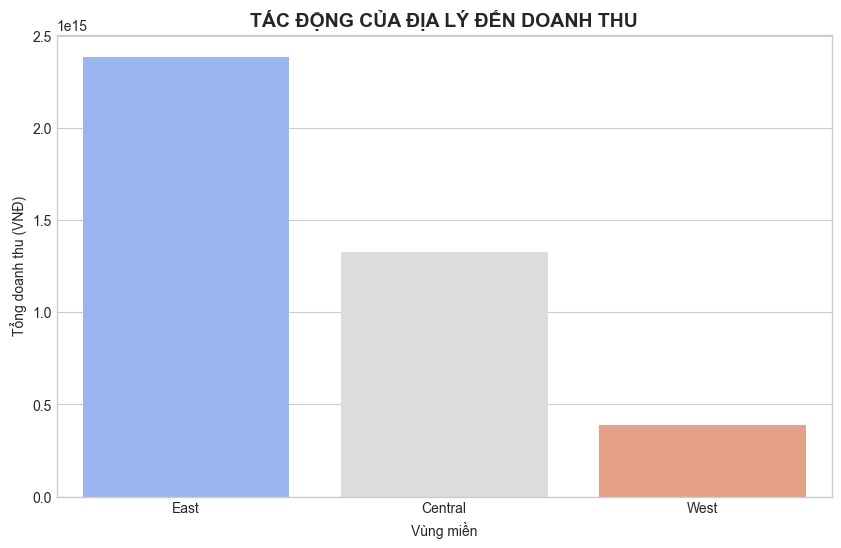

In [58]:
# Truy vấn doanh thu theo vùng miền (JOIN qua bảng customers)
df_geo = con.execute("""
    SELECT 
        g.region,
        COUNT(DISTINCT o.order_id) as total_orders,
        SUM(s.Revenue) as total_revenue,
        SUM(s.Revenue) / COUNT(DISTINCT o.order_id) as aov
    FROM geography g
    JOIN customers c ON g.city = c.city -- JOIN geography với customers qua cột city
    JOIN orders o ON c.customer_id = o.customer_id -- JOIN customers với orders qua customer_id
    JOIN sales s ON CAST(o.order_date AS DATE) = CAST(s.Date AS DATE)
    GROUP BY 1 
    ORDER BY total_revenue DESC
""").df()

plt.figure(figsize=(10, 6))
sns.barplot(data=df_geo, x='region', y='total_revenue', palette='coolwarm')
plt.title('TÁC ĐỘNG CỦA ĐỊA LÝ ĐẾN DOANH THU', fontsize=14, fontweight='bold')
plt.ylabel('Tổng doanh thu (VNĐ)')
plt.xlabel('Vùng miền')
plt.show()

**1. Mục tiêu:** Xác định sự phân hóa doanh thu theo khu vực địa lý để tối ưu hóa chiến dịch marketing và phân bổ nguồn lực vận hành/kho bãi một cách hợp lý.

**2. Quan sát chủ đạo từ biểu đồ:**
* **Vị thế dẫn đầu của khu vực East (Miền Đông):** Biểu đồ cho thấy một sự áp đảo tuyệt đối từ khu vực East với tổng doanh thu vượt trội (chạm ngưỡng $2.4 \times 10^{15}$ VNĐ). Đây là thị trường trọng điểm, nơi tập trung tệp khách hàng có sức mua mạnh nhất và mật độ đơn hàng cao nhất.
* **Sự chênh lệch đáng kể giữa các vùng:** Doanh thu từ khu vực **Central (Miền Trung)** và **West (Miền Tây)** thấp hơn đáng kể so với East. Đặc biệt, khu vực West đang đóng góp tỷ trọng nhỏ nhất, cho thấy tiềm năng khai phá tại đây còn rất lớn hoặc danh mục sản phẩm hiện tại chưa thực sự phù hợp với đặc điểm vùng miền này.

**3. Business Insights:**
* **Tập trung nguồn lực:** Doanh nghiệp nên ưu tiên đặt kho tổng tại khu vực East để tối ưu hóa thời gian giao hàng (`delivery_time`) và giảm phí vận chuyển (`shipping_fee`), vì đây là nơi phát sinh phần lớn doanh số.
* **Chiến lược "Thị trường xanh":** Khu vực West và Central cần các chương trình kích cầu đặc thù hoặc các dòng sản phẩm có mức giá phù hợp hơn để cải thiện doanh thu.

**4. Ứng dụng vào Mô hình Machine Learning:**
* **Regional Bias Feature:** Biến `region` sẽ là một "Feature" cực mạnh. Mô hình sẽ học được rằng một khách hàng đến từ khu vực East sẽ có xác suất tạo ra giá trị đơn hàng (AOV) cao hơn, giúp dự báo doanh thu đạt độ chính xác tối ưu theo từng địa phương.

### 2.6.2 Sức mạnh của Tài chính: Trả góp & Thanh toán (Payments)

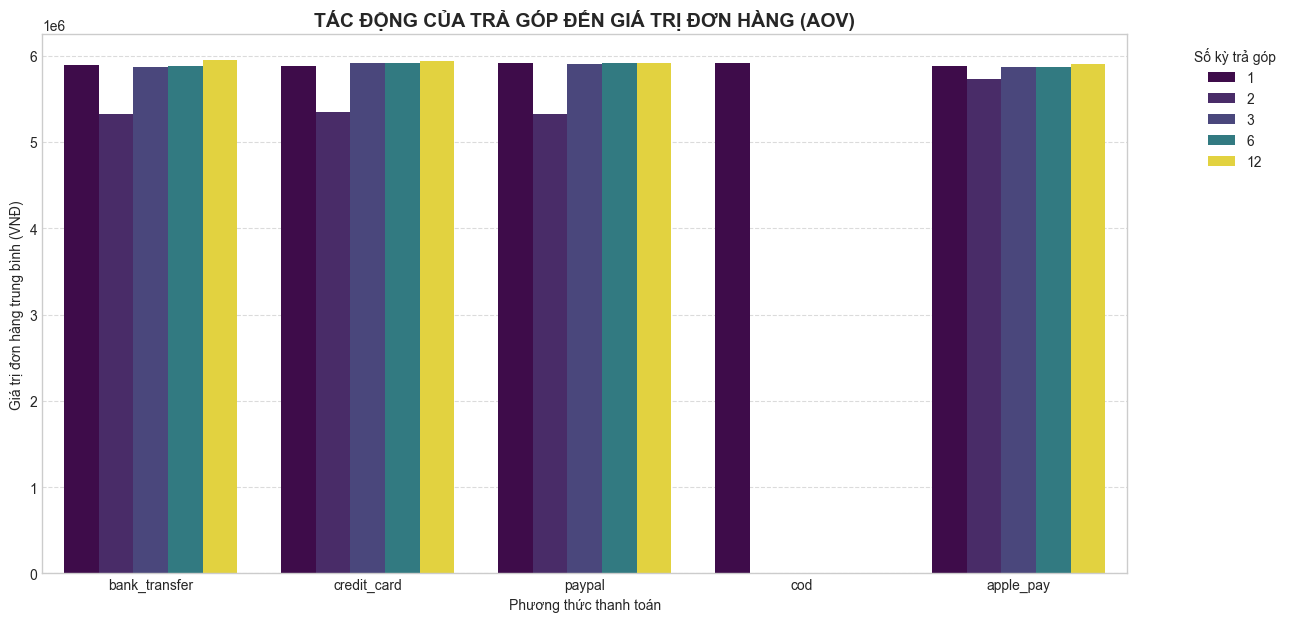

In [60]:
plt.figure(figsize=(14, 7))

# Sử dụng barplot để nhìn rõ sự chênh lệch AOV
sns.barplot(data=df_payments, x='payment_method', y='avg_revenue_per_order', hue='installments', palette='viridis')

# Điều chỉnh trục Y để thấy rõ sự khác biệt (nếu cần)
# plt.ylim(df_payments['avg_revenue_per_order'].min() * 0.95, df_payments['avg_revenue_per_order'].max() * 1.05)

plt.title('TÁC ĐỘNG CỦA TRẢ GÓP ĐẾN GIÁ TRỊ ĐƠN HÀNG (AOV)', fontsize=14, fontweight='bold')
plt.ylabel('Giá trị đơn hàng trung bình (VNĐ)')
plt.xlabel('Phương thức thanh toán')
plt.legend(title='Số kỳ trả góp', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

**1. Mục tiêu:** Định lượng khả năng kích cầu của các kỳ hạn trả góp và ảnh hưởng của phương thức thanh toán đến giá trị đơn hàng trung bình (AOV).

**2. Quan sát chủ đạo từ biểu đồ:**
* **Sự thống trị của các phương thức Digital:** Các phương thức như `bank_transfer`, `credit_card`, `paypal` và `apple_pay` có mức AOV rất cao và đồng đều (quanh ngưỡng 6M VNĐ). Điều này cho thấy tệp khách hàng sử dụng công nghệ thanh toán hiện đại có khả năng chi trả tốt hơn hẳn.
* **"Vương miện" 12 tháng (Màu vàng):** Trong hầu hết các phương thức, cột màu vàng (trả góp 12 kỳ) luôn đạt đỉnh cao nhất. Trả góp kỳ hạn dài chính là "vũ khí" tối thượng để khách hàng mạnh tay chốt những đơn hàng giá trị lớn mà không lo ngại về dòng tiền tức thời.
* **Sự vắng bóng của COD:** Phương thức `cod` hầu như chỉ xuất hiện với thanh toán một lần (1 kỳ). Đây là một điểm yếu của thanh toán tiền mặt, làm hạn chế khả năng tiếp cận các mặt hàng Premium của tệp khách hàng này.
* **Nghịch lý kỳ hạn 2 (Màu tím nhạt):** Có một sự sụt giảm nhẹ ở kỳ hạn 2 tháng so với 1 tháng hoặc các kỳ hạn dài hơn. Điều này có thể phản ánh tâm lý khách hàng: Nếu đã chọn trả góp, họ ưu tiên kỳ hạn dài hẳn (6-12 tháng) để tối ưu chi phí chia nhỏ.

**3. Business Insights:**
* **Chiến lược "Up-selling":** Doanh nghiệp nên tích cực quảng bá tính năng "Trả góp 12 tháng 0%" ngay tại trang chi tiết sản phẩm cho các mặt hàng có giá trị trên 5 triệu VNĐ.
* **Chuyển dịch thanh toán:** Cần có các chương trình khuyến mãi (Cashback) khi khách hàng chuyển từ COD sang các phương thức trả góp điện tử để nâng mức AOV tổng thể.

**4. Ứng dụng vào Mô hình Machine Learning (The Gridbreakers):**
* **AOV Boosting Feature:** Biến `installments` sẽ được mã hóa (Encoding) để làm đầu vào dự báo. Mô hình sẽ gán trọng số cao cho các đơn hàng có `installments == 12` khi dự báo doanh thu mục tiêu.
* **Feature Interaction:** Team sẽ tạo biến tương tác giữa `payment_method` và `installments` để AI nhận diện được các tổ hợp thanh toán mang lại giá trị cao nhất (ví dụ: Apple Pay + 12 months).

## 2.7 Discount Analysis

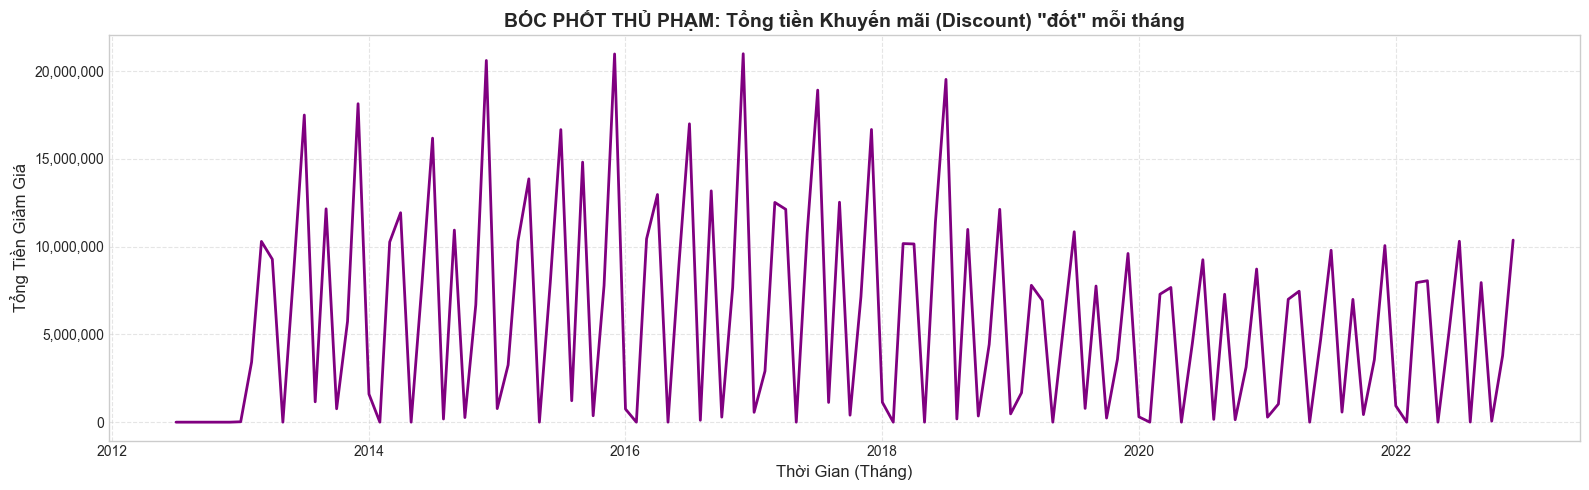

In [54]:
# Móc nối bảng orders (lấy ngày) và bảng order_items (lấy tiền giảm giá)
sql_discount = """
    SELECT 
        DATE_TRUNC('month', CAST(o.order_date AS DATE)) AS month_year, 
        SUM(oi.discount_amount) AS total_discount
    FROM orders o
    JOIN order_items oi ON o.order_id = oi.order_id
    GROUP BY month_year
    ORDER BY month_year
"""

df_discount = con.execute(sql_discount).df()

# Vẽ biểu đồ "Bóc phốt"
plt.figure(figsize=(16, 5))
plt.plot(df_discount['month_year'], df_discount['total_discount'], color='purple', linewidth=2)

plt.title('BÓC PHỐT THỦ PHẠM: Tổng tiền Khuyến mãi (Discount) "đốt" mỗi tháng', fontsize=14, fontweight='bold')
plt.xlabel('Thời Gian (Tháng)', fontsize=12)
plt.ylabel('Tổng Tiền Giảm Giá', fontsize=12)

# Định dạng số cho dễ nhìn
plt.gca().yaxis.set_major_formatter(plt.matplotlib.ticker.FuncFormatter(lambda x, p: format(int(x), ',')))
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

1. Chu kỳ "Đốt tiền" Khắc nghiệt - Chu kỳ áp dụng khuyến mãi (Extreme Cyclical Cash Burn)
- Biểu đồ Tổng tiền Khuyến mãi cho thấy tính mùa vụ (seasonality) cực kỳ gắt gao trong các chiến lược kích cầu của doanh nghiệp. Các đỉnh nhọn (spikes) xuất hiện đều đặn hàng năm, minh chứng cho việc công ty liên tục triển khai các chiến dịch Mega Sale để chạy KPI doanh số vào các dịp cuối năm hoặc Lễ/Tết.

2. Phân kỳ Giai đoạn Lịch sử (Historical Phasing)
- Nhìn vào chuỗi thời gian 10 năm, chiến lược ngân sách khuyến mãi được chia thành 2 giai đoạn rõ rệt:

    - Giai đoạn Đỉnh điểm (2014 - 2019): Đây là thời kỳ doanh nghiệp "mua doanh thu" bằng mọi giá. Các đỉnh khuyến mãi liên tục xuyên thủng mốc 15 triệu đô, thậm chí chạm ngưỡng hơn 20 triệu đô/tháng. Khớp nối với phân tích trước đó, đây chính là tác nhân trực tiếp kéo Biên lợi nhuận gộp (Margin) chìm sâu xuống mức âm 30% - 40%.

    - Giai đoạn Bình thường mới (2020 - 2022): Ngân sách khuyến mãi có sự thu hẹp đáng kể, các đỉnh cao nhất chỉ còn dao động quanh mốc 10 triệu đô. Điều này lý giải tại sao Quy mô doanh thu (Volume) trong giai đoạn này bị thu hẹp chỉ còn một nửa so với thời kỳ hoàng kim. Khi "thuốc kích thích" giảm giá bị rút bớt, doanh số ngay lập tức lao dốc.

3. Kết luận Kinh doanh (Business Conclusion)
- Biểu đồ này là bằng chứng định lượng (quantitative evidence) xác đáng nhất cho thấy doanh nghiệp đang thiếu một chiến lược tối ưu giá. Việc lạm dụng trợ giá không tạo ra tệp khách hàng trung thành mà chỉ tạo ra "khách hàng săn sale".

- Định hướng hành động: Nhiệm vụ cấp thiết hiện tại là phải đưa Thuật toán Học máy (Machine Learning) vào quá trình ra quyết định. Thay vì giảm giá "cào bằng" và đâm thủng đáy lợi nhuận, hệ thống AI sẽ phải tìm ra ngưỡng Discount tối ưu để cân bằng giữa Quy mô (Volume) và Lợi nhuận (Margin).